# 14.5.2 同一预算下的外推比较

## 学习目标与先修知识

统一训练轨迹（trajectory）与预测时域，分别汇报预测、总量与非负性（nonnegativity）证据。

先修：14.1—14.4 四种表示与拟合；8.3 训练、验证和测试划分。

## 具体问题

机制模型（model）、低秩（rank）投影（projection）与线性辨识都能在训练轨迹上作图。给它们同样的新初值（initial condition）和评估时域后，哪一个错误来自表示不足，哪一个来自结构破坏？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

把同一条真实轨迹和一个故意丢失快方向的预测并列，先从初始时刻判断表示误差。

In [2]:
L=np.array([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]])
step=np.eye(3)-.05*L
state=np.array([3.,0.,0.]);start=state.copy()
for _ in range(20):state=step@state
print('真实初值',start,'；终点',np.round(state,4))

真实初值 [3. 0. 0.] ；终点 [1.5571 0.9612 0.4817]


## 模型假设

所有模型使用同一无输入（input）三室交换、相同训练轨迹、时间步 $h=.05T$、留出初值与预测长度。真实矩阵（matrix） $L$ 只交给机制基线与最终核验；纯数据方法只取训练配对快照。训练路径来自 $[2,1,0]$，新初值 $[3,0,0]$ 不参与拟合。机制基线与数据方法使用的先验（prior）知识分别记录。

## 数学解释与推导

在固定 $N$ 个时刻、$n$ 室下，状态（state）误差 $\mathrm{RMSE}=\sqrt{\sum_{k,i}(\hat x_{ki}-x_{ki})^2/(Nn)}$；总量差取 $\max_k|\mathbf1^\mathsf T(\hat x_k-x_k)|$；负值数是所有 $\hat x_{ki}<-10^{-10}$ 的计数。低秩模型还需报初值投影误差，DMD 报训练一步残差（residual）和留出滚动误差。训练与留出预算一致才可比较证据，但已知机制与数据拟合的先验并不相同。噪声重复用预定随机种子（random seed）描述波动，不能挑最好一次。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def dmd_fit(past, future, rank):
    """Fit Y X_r^+ with zero singular directions discarded."""
    x = np.asarray(past, dtype=float)
    y = np.asarray(future, dtype=float)
    left, singular, right_t = np.linalg.svd(x, full_matrices=False)
    keep = min(rank, len(singular))
    if keep == 0:
        return np.zeros((x.shape[0], x.shape[0])).tolist()
    cutoff = 1e-12 * singular[0]
    inverse = np.divide(1., singular[:keep],
                        out=np.zeros(keep), where=singular[:keep] > cutoff)
    operator = (y @ right_t[:keep].T * inverse) @ left[:, :keep].T
    return operator.tolist()


def linear_roll(operator, initial, steps):
    """Include the initial state, then repeatedly apply a fixed operator."""
    matrix = np.asarray(operator, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.tolist()]
    for _ in range(steps):
        state = matrix @ state
        history.append(state.tolist())
    return history


def path_metrics(truth, prediction, weights):
    actual = np.asarray(truth, dtype=float)
    proposed = np.asarray(prediction, dtype=float)
    weights = np.asarray(weights, dtype=float)
    rmse = float(np.sqrt(np.mean((actual-proposed)**2)))
    balance = float(np.max(np.abs((proposed-actual) @ weights)))
    negatives = int(np.count_nonzero(proposed < -1e-10))
    return [rmse, balance, negatives]


def centered_basis(snapshots, rank):
    """Fit mean and orthonormal basis on training columns only."""
    data = np.asarray(snapshots, dtype=float)
    mean = np.mean(data, axis=1)
    left, values, _ = np.linalg.svd(data - mean[:, None], full_matrices=False)
    return mean, left[:, :rank], values


def reduced_euler(laplacian, basis, mean, initial, dt, steps):
    """Euler on a Galerkin projection; the first state is projected."""
    lap = np.asarray(laplacian, dtype=float)
    vectors = np.asarray(basis, dtype=float)
    center = np.asarray(mean, dtype=float)
    x0 = np.asarray(initial, dtype=float)
    coordinates = vectors.T @ (x0 - center)
    history = [(center + vectors @ coordinates).tolist()]
    for _ in range(steps):
        state = center + vectors @ coordinates
        coordinates = coordinates - dt * (vectors.T @ (lap @ state))
        history.append((center + vectors @ coordinates).tolist())
    return history


def edmd_fit(feature_past, feature_next, ridge):
    """Features are columns; K acts from the left on feature vectors."""
    x = np.asarray(feature_past, dtype=float)
    y = np.asarray(feature_next, dtype=float)
    if ridge == 0:
        return (y @ np.linalg.pinv(x, rcond=1e-12)).tolist()
    gram = x @ x.T + ridge * np.eye(x.shape[0])
    return np.linalg.solve(gram, x @ y.T).T.tolist()


def lifted_roll(operator, readout, initial_feature, steps):
    matrix = np.asarray(operator, dtype=float)
    output = np.asarray(readout, dtype=float)
    feature = np.asarray(initial_feature, dtype=float)
    states = [(output @ feature).tolist()]
    for _ in range(steps):
        feature = matrix @ feature
        states.append((output @ feature).tolist())
    return states


def sparse_stlsq(theta, derivative, threshold, max_iter):
    """Column-normalized sequential thresholded least squares."""
    library = np.asarray(theta, dtype=float)
    target = np.asarray(derivative, dtype=float)
    scales = np.linalg.norm(library, axis=0)
    safe = np.where(scales > 0, scales, 1.)
    normalized = library / safe
    coefficient = np.linalg.lstsq(normalized, target, rcond=None)[0]
    support = np.abs(coefficient) >= threshold
    for _ in range(max_iter):
        if not np.any(support):
            coefficient[:] = 0
            break
        updated = np.zeros_like(coefficient)
        updated[support] = np.linalg.lstsq(normalized[:, support], target, rcond=None)[0]
        new_support = np.abs(updated) >= threshold
        coefficient = updated
        if np.array_equal(new_support, support):
            break
        support = new_support
    support = np.abs(coefficient) >= threshold
    coefficient[~support] = 0
    return [(coefficient / safe).tolist(), np.flatnonzero(support).tolist()]

## 对照实验

在相同训练轨迹上取得低秩基、DMD、有限字典与稀疏线性候选；与已知机制基线在相同留出初值上比较，再固定种子重复 DMD 的观测（observation）扰动。

机制 RMSE/总量误差/负值数 [0.0, 0.0, 0]
低秩 RMSE/总量误差/负值数 [0.2927575059692337, 2.3314683517128287e-15, 8]
DMD RMSE/总量误差/负值数 [0.248791948205327, 1.6486811915683575e-14, 7]
有限字典 RMSE/总量误差/负值数 [0.2487919482053267, 1.8762769116165146e-14, 7]
稀疏线性候选 RMSE/总量误差/负值数 [0.5455535368441405, 4.551914400963142e-15, 0]


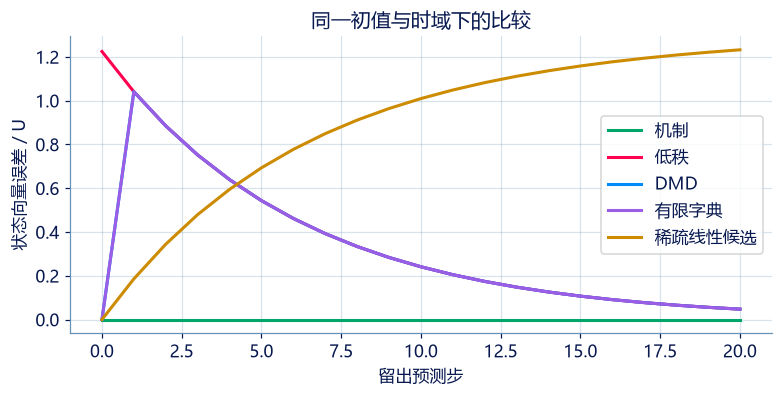

10次含噪 DMD 留出 RMSE 范围 0.2459 0.2523
只观测第一室时的留出第一室 RMSE 0.4993
第11步开始加入新输入后，无输入 DMD 的末步误差 0.85214


In [4]:
L=np.array([[1.,-1.,0.],[-1.,2.,-1.],[0.,-1.,1.]])
step=np.eye(3)-.05*L
train=np.asarray(linear_roll(step,[2.,1.,0.],40));X=train[:-1].T;Y=train[1:].T
mean,basis,_=centered_basis(train.T,1)
held=[3.,0.,0.];truth=np.asarray(linear_roll(step,held,20))
mechanism=np.asarray(linear_roll(step,held,20))
pod=np.asarray(reduced_euler(L,basis.tolist(),mean.tolist(),held,.05,20))
dmd=np.asarray(linear_roll(dmd_fit(X,Y,2),held,20))
features=np.vstack([np.ones(X.shape[1]),X]);next_features=np.vstack([np.ones(Y.shape[1]),Y])
lift_operator=edmd_fit(features,next_features,0.)
edmd=np.asarray(lifted_roll(lift_operator,np.column_stack([np.zeros(3),np.eye(3)]),[1.,*held],20))
derivative=(Y-X)/.05
sparse_matrix=np.asarray([sparse_stlsq(X.T,derivative.T[:,i],.01,8)[0] for i in range(3)])
sparse=np.asarray(linear_roll(np.eye(3)+.05*sparse_matrix,held,20))
fig,ax=plt.subplots(figsize=(7,3.5))
for label,path,color in [('机制',mechanism,GREEN),('低秩',pod,PINK),('DMD',dmd,BLUE),('有限字典',edmd,'#9b5de5'),('稀疏线性候选',sparse,'#cc8b00')]:
    ax.plot(np.linalg.norm(path-truth,axis=1),label=label,color=color)
    print(label,'RMSE/总量误差/负值数',path_metrics(truth,path,[1,1,1]))
ax.set(xlabel='留出预测步',ylabel='状态向量误差 / U',title='同一初值与时域下的比较');ax.grid(alpha=.25);ax.legend();plt.show()
noise_scores=[]
for seed in range(10):
    rng=np.random.default_rng(seed)
    noisy=train+rng.normal(0,.01,train.shape)
    fitted=dmd_fit(noisy[:-1].T,noisy[1:].T,2)
    path=np.asarray(linear_roll(fitted,held,20))
    noise_scores.append(path_metrics(truth,path,[1,1,1])[0])
print('10次含噪 DMD 留出 RMSE 范围',round(min(noise_scores),4),round(max(noise_scores),4))
# 单通道观测是另一个任务，不并入上面全状态模型的公平比较。
single_operator=dmd_fit(train[:-1,0][None,:],train[1:,0][None,:],1)
single_prediction=np.asarray(linear_roll(single_operator,[held[0]],20))[:,0]
print('只观测第一室时的留出第一室 RMSE',round(np.sqrt(np.mean((single_prediction-truth[:,0])**2)),5))
input_state=np.array(held,dtype=float);input_truth=[input_state.copy()]
for index in range(20):
    input_state=step@input_state+(np.array([.1,0,0]) if index>=10 else 0)
    input_truth.append(input_state.copy())
print('第11步开始加入新输入后，无输入 DMD 的末步误差',round(np.linalg.norm(dmd[-1]-input_truth[-1]),5))

## 结果解释

机制基线使用已知生成矩阵，因而离散模型误差为零。训练轨迹未激发快方向，低秩模型在投影新初态时就丢失了这部分；DMD、有限字典与稀疏候选也面临同样的数据缺口。

几个对照分别回答不同问题：含噪重复检查 DMD 对观测扰动的敏感性；只观测第一室时，评价对象缩为该室的输出（output）；新增输入则要求模型具有输入通道。结合各自的误差、守恒差和负值，才能解释这些变化。

### 独立核对

独立核对已知机制的留出轨迹和总量；明确比较的初始时刻误差与训练一步残差不同。

In [5]:
np.testing.assert_allclose(mechanism,truth)
np.testing.assert_allclose(truth.sum(axis=1),3.,atol=1e-12)
assert np.linalg.norm(pod[0]-truth[0])>.5
assert np.linalg.norm(Y-np.asarray(dmd_fit(X,Y,2))@X)<1e-10
assert np.isfinite(edmd).all() and np.isfinite(sparse).all()
assert len(noise_scores)==10 and np.isfinite(noise_scores).all()
assert single_prediction.shape == truth[:,0].shape
assert np.linalg.norm(dmd[-1]-input_truth[-1])>np.linalg.norm(dmd[-1]-truth[-1])
print('机制真值、守恒、留出投影与训练残差核验通过。')

机制真值、守恒、留出投影与训练残差核验通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：同一时域下报告失败

给定等形状真值与预测轨迹（trajectory），按题定规则返回逐元素 RMSE、加权总量差的时间最大值及显著负值个数。

**函数与代码模板**

```python
def solve(
    truth: list[list[float]],
    prediction: list[list[float]],
    weights: list[float],
) -> tuple[float, float, int]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `truth` | `list[list[float]]` | N×n 真实状态（state）。 | U |
| `prediction` | `list[list[float]]` | N×n 预测状态。 | U |
| `weights` | `list[float]` | n 个总量权重；各室总量时均为1。 | 1 |

**返回值**

按以下顺序返回元组：(rmse, max_balance, negatives)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rmse` | `float` | 所有 Nn 元素的均方根误差（root mean squared error，RMSE）。 | U |
| `max_balance` | `float` | 各时刻 weights·(prediction−truth) 绝对值最大值。 | U |
| `negatives` | `int` | prediction 中低于 −10⁻¹⁰ 的元素个数。 | 个 |

**计算规则**

预测轨迹包括失败时刻，不得删去。max_balance 衡量相对于真值的加权总量差，不等同于单条预测轨迹对其自身初值（initial condition）的漂移。

**约束与边界**

- N,n≥1，三组维度相容，全部数值有限。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| truth | N×n 真实状态（state）。 | [[1.0, 1.0], [1.0, 1.0]] | U |
| prediction | N×n 预测状态。 | [[1.0, 1.0], [1.2, 0.8]] | U |
| weights | n 个总量权重；各室总量时均为1。 | [1.0, 1.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
truth = [[1.0, 1.0], [1.0, 1.0]]
prediction = [[1.0, 1.0], [1.2, 0.8]]
weights = [1.0, 1.0]

result = solve(truth, prediction, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rmse | 所有 Nn 元素的均方根误差（root mean squared error，RMSE）。 | ≈ 0.1414214 | U |
| max_balance | 各时刻 weights·(prediction−truth) 绝对值最大值。 | 0 | U |
| negatives | prediction 中低于 −10⁻¹⁰ 的元素个数。 | 0 | 个 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.14142135623730948, 0.0, 0)
```

**样例解释**

首例第二时刻两室误差互相抵消，总量差为0，但逐元素 RMSE 仍大于0。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：同一时域下报告失败](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-path-metrics)

### 第 2 题 · 单项选择题：怎样比较不同模型

比较机制、低秩（rank）和数据传播时，什么必须固定并公开？

- **A.** 训练来源、观测（observation）变量、留出条件、预测时域与各方法先验（prior）。
- **B.** 只固定图形颜色。
- **C.** 给数据方法留出真值参数（parameter）却说它只用观测。
- **D.** 删除失败轨迹（trajectory）后再汇总。

[作答：怎样比较不同模型](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-fair-budget)

### 第 3 题 · 单项选择题：t=0 错误从哪里来

降阶模型（model）在 t=0 已偏离留出初值（initial condition），完整 Euler 尚未更新。先检查什么？

- **A.** 训练基对新初值的投影（projection）误差。
- **B.** Euler 时间步是否足够小。
- **C.** 绘图采样（sampling）点数。
- **D.** 只报告训练能量比例。

[作答：t=0 错误从哪里来](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-initial-error)

### 第 4 题 · 单项选择题：重复观测噪声实验

10 次预定种子下的预测误差差异较大，怎样报告较合适？

- **A.** 给出重复的范围或分布（distribution），并保留固定的独立评估条件。
- **B.** 只选择误差最低一次当作典型结果。
- **C.** 把所有不同种子都当成新生物机制。
- **D.** 在测试轨迹（trajectory）上挑选种子再报告独立测试。

[作答：重复观测噪声实验](http://127.0.0.1:8000/chapters/14-05-%E5%99%AA%E5%A3%B0%E3%80%81%E5%A4%96%E6%8E%A8%E4%B8%8E%E7%BB%93%E6%9E%84%E4%BF%9D%E6%8C%81/practice/?question=p14-repeat-noise)

**进一步阅读**

[Brunton 与 Kutz 的数据驱动科学教材](https://www.cambridge.org/highereducation/books/data-driven-science-and-engineering/6F9A730B7A9A9F43F68CF21A24BEC339/contents/F7A59AEF64F3A226EEADD2F1DDD4F083)用于方法比较背景；此处所有实验定义和限制已给出。